## Purpose of this notebook

Every later result in this project is only meaningful relative to a reference point. Without a yardstick there is no way to tell whether feature engineering, class-imbalance handling, or hyperparameter tuning actually help — a number in isolation says nothing. This notebook establishes that yardstick before any modelling decisions are made.

Three reference points are recorded. The **no-skill floor** is a `DummyClassifier` that always predicts the training prevalence; its PR-AUC equals the positive-class prevalence (≈ 0.14) and its ROC-AUC sits at 0.5. Any real model must clear this floor to be considered useful at all. **Logistic Regression** is the simplest transparent linear model; it is the model whose coefficients we may want to interpret later, and the one most likely to benefit from feature engineering in NB05. **LightGBM** with default hyperparameters and scale_pos_weight represents the strong tabular baseline: it handles non-linearity and feature interactions natively without any manual engineering. The gap between LogReg and LightGBM quantifies how much of the signal in this dataset is non-linear or interaction-driven — if the gap is small, a well-engineered linear model is competitive; if it is large, tree-based methods have a structural advantage that FE alone cannot close.

Every result produced in subsequent notebooks — NB05 (feature engineering experiments), NB06/NB07 (imbalance handling, tuning, stacking) — is only counted as progress if it beats the corresponding baseline here by more than the CV standard deviation. Improvements within the noise band are not improvements.

The VIF check in Section 5 is included specifically to assess whether LogReg coefficients are interpretable. Variance inflation factors quantify multicollinearity among the predictors; high VIF on a feature means its coefficient is unstable and should not be read in isolation. Trees are entirely immune to multicollinearity and do not need this check. Crucially, VIF here is a **diagnostic for interpretability only** — it is not a feature filter. No feature is dropped or penalised based on VIF. All 21 raw features are carried forward unchanged into every subsequent notebook.

Leakage discipline: the test set is not loaded anywhere in this notebook (it is frozen for the one-time evaluation in NB08). All learnable steps — the StandardScaler — are fitted exclusively inside CV folds via an `ImbPipeline`. The cross-validation uses `StratifiedGroupKFold` to match NB03's profile-based split: rows that share an identical 21-feature profile are kept together so the CV mirrors real hold-out conditions. `StratifiedGroupKFold` combines two guarantees: *group-aware* (rows with an identical 21-feature profile stay in the same fold, so the ~14% duplicate profiles cannot leak across the train/validation boundary) and *stratified* (the ~14% positive prevalence is preserved approximately in every fold, so per-fold PR-AUC is comparable and not distorted by an unlucky class split). The folds are shuffled with shuffle=True, random_state=SEED, so the partition is reproducible and uses the same seed as NB03's train/test split Class imbalance is handled in-fold via `class_weight="balanced"` for LogReg and `scale_pos_weight` for LightGBM; SMOTE is a more expensive alternative evaluated in NB06.

## 1. Setup

Libraries are installed if missing and imported centrally. The global seed is set once and reused across every randomised step.

In [1]:
# install required packages if missing
import importlib.util, subprocess, sys
for pkg, import_name in [("lightgbm", "lightgbm"), ("imbalanced-learn", "imblearn"), ("statsmodels", "statsmodels")]:
    if importlib.util.find_spec(import_name) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])

import warnings
warnings.simplefilter("ignore", category=FutureWarning)

import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedGroupKFold, cross_validate
from imblearn.pipeline import Pipeline as ImbPipeline
from lightgbm import LGBMClassifier
from statsmodels.stats.outliers_influence import variance_inflation_factor

plt.rcParams["figure.dpi"] = 110
sns.set_theme(style="whitegrid")

SEED = 42

PROJECT_ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "notebooks").is_dir())
DATA_DIR   = PROJECT_ROOT / "data" / "processed"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "nb04"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_CSV = PROJECT_ROOT / "outputs" / "results.csv"

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
from src.utils import log_result

## 2. Load training data

Only the training split is loaded — the test set remains frozen. The feature metadata from NB03 provides the canonical column ordering and the seed value.

In [2]:
with open(DATA_DIR / "feature_meta.json") as f:
    feature_meta = json.load(f)

ALL_FEATURES = feature_meta["all_features"]
SEED = feature_meta["seed"]

X_train = pd.read_parquet(DATA_DIR / "X_train.parquet")
y_train = pd.read_parquet(DATA_DIR / "y_train.parquet").squeeze("columns")

# reindex to canonical feature order defined in feature_meta.json
X_train = X_train[ALL_FEATURES]

assert X_train.shape[1] == 21, f"Expected 21 features, got {X_train.shape[1]}"
assert set(X_train.columns) == set(ALL_FEATURES), "Column set mismatch with feature_meta.json"
assert len(X_train) == len(y_train), "Feature/target length mismatch"

# profile-based group labels: rows with identical 21-feature vector share a group ID
groups = pd.util.hash_pandas_object(X_train, index=False).values

prevalence = y_train.mean()
print(f"n_samples       : {len(X_train):,}")
print(f"unique groups   : {len(set(groups)):,}")
print(f"positive prev.  : {prevalence:.4f}  (no-skill PR-AUC floor \u2248 {prevalence:.4f})")

n_samples       : 202,943
unique groups   : 182,337
positive prev.  : 0.1393  (no-skill PR-AUC floor ≈ 0.1393)


## 3. No-skill baseline (PR-AUC floor)

A `DummyClassifier` with `strategy="prior"` always predicts the training class probabilities regardless of the input — it carries no signal at all. Its PR-AUC equals the positive-class prevalence because Precision-Recall space is anchored by how often the positive class occurs: a classifier that outputs a constant positive probability achieves exactly `p` precision at every recall level, yielding an area equal to `p`. Its ROC-AUC sits at 0.5 for the same reason — random ordering of positives and negatives.

Accuracy is not used as a primary metric here: on an 86/14 split, a classifier that predicts the majority class 100% of the time achieves ~86% accuracy, which is a meaningless number. PR-AUC makes the imbalance visible by measuring performance specifically on the minority class (Saito & Rehmsmeier, 2015).

In [3]:
cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
SCORING = ["average_precision", "roc_auc"]

dummy = DummyClassifier(strategy="prior")
dummy_scores = cross_validate(
    dummy, X_train, y_train, groups=groups,
    cv=cv, scoring=SCORING, n_jobs=-1
)

dummy_prauc = dummy_scores["test_average_precision"].mean()
dummy_rocauc = dummy_scores["test_roc_auc"].mean()

print(f"Dummy PR-AUC  : {dummy_prauc:.4f}  (expected \u2248 prevalence {prevalence:.4f})")
print(f"Dummy ROC-AUC : {dummy_rocauc:.4f}  (expected \u2248 0.50)")

Dummy PR-AUC  : 0.1393  (expected ≈ prevalence 0.1393)
Dummy ROC-AUC : 0.5000  (expected ≈ 0.50)


## 4. Baseline models under group-aware CV

Both models use in-fold class-imbalance handling. LogReg uses `class_weight="balanced"`, which reweights the loss inversely proportional to class frequencies. LightGBM uses `scale_pos_weight = n_negative / n_positive`, the equivalent parameter for boosting. The StandardScaler is inside the `ImbPipeline` so it is fitted only on the training fold — no leakage.

In [4]:
spw = float((y_train == 0).sum() / (y_train == 1).sum())

logreg_pipe = ImbPipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(class_weight="balanced", max_iter=2000, random_state=SEED)),
])

lgbm_clf = LGBMClassifier(scale_pos_weight=spw, verbose=-1, random_state=SEED, n_jobs=-1)

lr_scores = cross_validate(
    logreg_pipe, X_train, y_train, groups=groups,
    cv=cv, scoring=SCORING, n_jobs=-1
)

lgbm_scores = cross_validate(
    lgbm_clf, X_train, y_train, groups=groups,
    cv=cv, scoring=SCORING, n_jobs=-1
)

results = pd.DataFrame({
    "model": ["Dummy", "LogisticRegression", "LightGBM"],
    "pr_auc_mean": [
        dummy_scores["test_average_precision"].mean(),
        lr_scores["test_average_precision"].mean(),
        lgbm_scores["test_average_precision"].mean(),
    ],
    "pr_auc_std": [
        dummy_scores["test_average_precision"].std(),
        lr_scores["test_average_precision"].std(),
        lgbm_scores["test_average_precision"].std(),
    ],
    "roc_auc_mean": [
        dummy_scores["test_roc_auc"].mean(),
        lr_scores["test_roc_auc"].mean(),
        lgbm_scores["test_roc_auc"].mean(),
    ],
})

results.to_csv(OUTPUT_DIR / "baseline_cv_scores.csv", index=False)
print(results.to_string(index=False))

             model  pr_auc_mean  pr_auc_std  roc_auc_mean
             Dummy     0.139330    0.000009      0.500000
LogisticRegression     0.404127    0.007567      0.823109
          LightGBM     0.434271    0.009054      0.830155


In [5]:
# log all three models to the shared results ledger
log_result(RESULTS_CSV, notebook="nb04", model="Dummy",
           pr_auc_mean=results.loc[results.model=="Dummy", "pr_auc_mean"].item(),
           pr_auc_std=results.loc[results.model=="Dummy", "pr_auc_std"].item(),
           roc_auc_mean=results.loc[results.model=="Dummy", "roc_auc_mean"].item(),
           feature_set="raw21", imbalance="none", n_folds=5, seed=SEED)

log_result(RESULTS_CSV, notebook="nb04", model="LogisticRegression",
           pr_auc_mean=results.loc[results.model=="LogisticRegression", "pr_auc_mean"].item(),
           pr_auc_std=results.loc[results.model=="LogisticRegression", "pr_auc_std"].item(),
           roc_auc_mean=results.loc[results.model=="LogisticRegression", "roc_auc_mean"].item(),
           feature_set="raw21", imbalance="class_weight", n_folds=5, seed=SEED)

log_result(RESULTS_CSV, notebook="nb04", model="LightGBM",
           pr_auc_mean=results.loc[results.model=="LightGBM", "pr_auc_mean"].item(),
           pr_auc_std=results.loc[results.model=="LightGBM", "pr_auc_std"].item(),
           roc_auc_mean=results.loc[results.model=="LightGBM", "roc_auc_mean"].item(),
           feature_set="raw21", imbalance="scale_pos_weight", n_folds=5, seed=SEED)

print("Logged to", RESULTS_CSV)

Logged to c:\Users\hashe\Downloads\Diabetes-Prediction-Hasher\outputs\results.csv


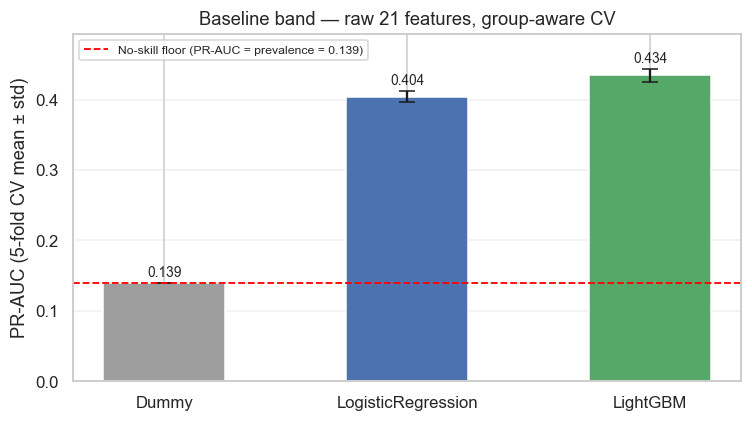

Saved c:\Users\hashe\Downloads\Diabetes-Prediction-Hasher\outputs\nb04\baseline_band.png


In [6]:
# bar chart: PR-AUC per model with std error bars + no-skill floor line
fig, ax = plt.subplots(figsize=(7, 4))

colors = ["#9E9E9E", "#4C72B0", "#55A868"]
bars = ax.bar(
    results["model"], results["pr_auc_mean"],
    yerr=results["pr_auc_std"], capsize=5,
    color=colors, edgecolor="white", width=0.5, error_kw={"linewidth": 1.5}
)

for bar, mean, std in zip(bars, results["pr_auc_mean"], results["pr_auc_std"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        mean + std + 0.005,
        f"{mean:.3f}",
        ha="center", va="bottom", fontsize=9
    )

ax.axhline(prevalence, color="red", linestyle="--", linewidth=1.2,
           label=f"No-skill floor (PR-AUC = prevalence = {prevalence:.3f})")

ax.set_ylabel("PR-AUC (5-fold CV mean \u00b1 std)")
ax.set_title("Baseline band \u2014 raw 21 features, group-aware CV", fontsize=12)
ax.legend(fontsize=8)
ax.set_ylim(0, results["pr_auc_mean"].max() + results["pr_auc_std"].max() + 0.05)
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()

fig.savefig(OUTPUT_DIR / "baseline_band.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved", OUTPUT_DIR / "baseline_band.png")

## 4b. Baseline curves (PR & ROC, out-of-fold)

Both curves are threshold-independent — every point corresponds to a different decision threshold — so they belong at the baseline stage. They are computed from out-of-fold predictions via `cross_val_predict` on the same group-aware CV, so no sample is scored by a model trained on it. The PR curve is read relative to the no-skill line (precision = prevalence).

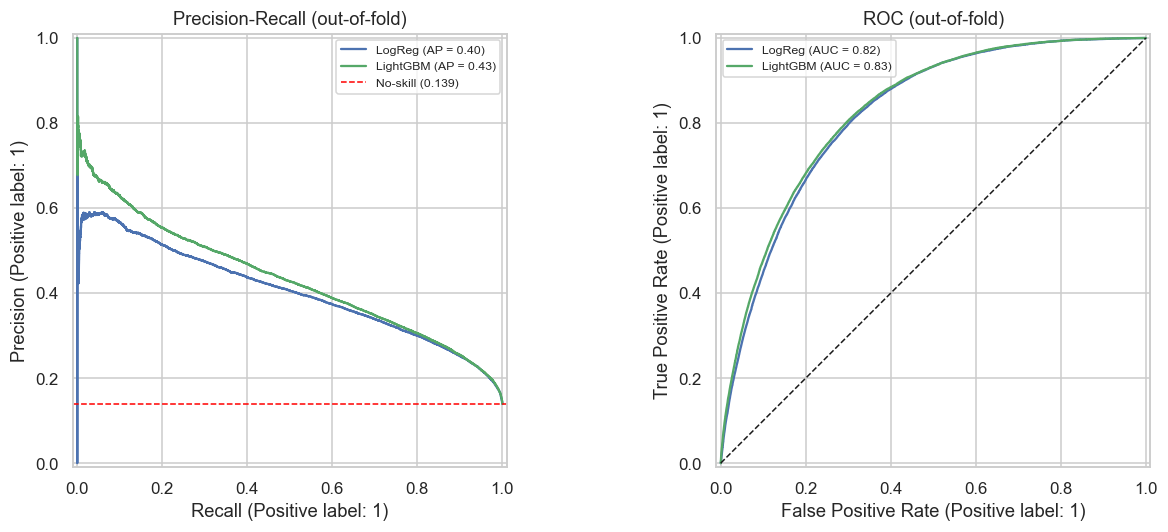

In [7]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import PrecisionRecallDisplay, RocCurveDisplay

fig, (axp, axr) = plt.subplots(1, 2, figsize=(12, 5))
for name, est, color in [("LogReg", logreg_pipe, "#4C72B0"), ("LightGBM", lgbm_clf, "#55A868")]:
    oof = cross_val_predict(est, X_train, y_train, groups=groups, cv=cv,
                            method="predict_proba", n_jobs=-1)[:, 1]
    PrecisionRecallDisplay.from_predictions(y_train, oof, name=name, ax=axp, color=color)
    RocCurveDisplay.from_predictions(y_train, oof, name=name, ax=axr, color=color)
axp.axhline(prevalence, color="red", ls="--", lw=1, label=f"No-skill ({prevalence:.3f})")
axp.set_title("Precision-Recall (out-of-fold)"); axp.legend(fontsize=8)
axr.plot([0, 1], [0, 1], "k--", lw=1); axr.set_title("ROC (out-of-fold)"); axr.legend(fontsize=8)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "baseline_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Multicollinearity check (VIF)

Variance inflation factors measure how much the variance of a regression coefficient is inflated due to collinearity with other predictors. A VIF of 1 means no correlation with other features; a VIF of 10 means the coefficient variance is 10× what it would be in an orthogonal design. The conventional rule-of-thumb thresholds (O'Brien, 2007) are: < 5 uncritical, 5–10 concerning, ≥ 10 severe.

This check is relevant **only for LogReg coefficient interpretation**. LightGBM (and gradient-boosted trees in general) are immune to multicollinearity — they do not estimate coefficients, and feature redundancy simply spreads importance across correlated features rather than destabilising individual splits. High VIF here does not indicate a problem for the tree model, and it does not justify dropping any feature. All 21 features are carried forward regardless of VIF.

In [8]:
X_scaled = StandardScaler().fit_transform(X_train[ALL_FEATURES])

vif_values = [
    variance_inflation_factor(X_scaled, i)
    for i in range(X_scaled.shape[1])
]

vif_df = pd.DataFrame({"feature": ALL_FEATURES, "VIF": vif_values})
vif_df["VIF"] = vif_df["VIF"].round(2)
vif_df["collinearity"] = pd.cut(
    vif_df["VIF"],
    bins=[-float("inf"), 5, 10, float("inf")],
    labels=["uncritical (<5)", "concerning (5\u201310)", "severe (\u226510)"]
)
vif_df = vif_df.sort_values("VIF", ascending=False).reset_index(drop=True)

vif_df.to_csv(OUTPUT_DIR / "vif.csv", index=False)
print(vif_df.to_string(index=False))

             feature  VIF    collinearity
             GenHlth 1.80 uncritical (<5)
            PhysHlth 1.63 uncritical (<5)
            DiffWalk 1.54 uncritical (<5)
              Income 1.51 uncritical (<5)
                 Age 1.35 uncritical (<5)
              HighBP 1.33 uncritical (<5)
           Education 1.33 uncritical (<5)
            MentHlth 1.24 uncritical (<5)
            HighChol 1.17 uncritical (<5)
HeartDiseaseorAttack 1.17 uncritical (<5)
        PhysActivity 1.16 uncritical (<5)
         NoDocbcCost 1.15 uncritical (<5)
                 BMI 1.14 uncritical (<5)
              Fruits 1.11 uncritical (<5)
       AnyHealthcare 1.11 uncritical (<5)
             Veggies 1.11 uncritical (<5)
              Smoker 1.09 uncritical (<5)
                 Sex 1.08 uncritical (<5)
              Stroke 1.08 uncritical (<5)
           CholCheck 1.03 uncritical (<5)
   HvyAlcoholConsump 1.02 uncritical (<5)


## 5b. Logistic-regression coefficients

Because all VIFs are < 5 (Section 5), the LogReg coefficients can be read individually. The model is fitted on the full training set here for **interpretation only** — its performance was estimated by cross-validation in Section 4. Features are standardised, so coefficients are directly comparable in magnitude, and `exp(coefficient)` is the odds ratio for a one-standard-deviation increase: > 1 raises the predicted diabetes odds, < 1 lowers them. This is the linear, model-based view of feature relevance — complementary to the non-linear view (permutation importance) examined on the final model in NB08.

             feature  coef_std  odds_ratio
             GenHlth     0.627       1.873
                 BMI     0.486       1.625
                 Age     0.457       1.579
              HighBP     0.364       1.440
            HighChol     0.286       1.331
           CholCheck     0.242       1.274
   HvyAlcoholConsump    -0.163       0.849
                 Sex     0.140       1.150
              Income    -0.118       0.889
HeartDiseaseorAttack     0.074       1.077
            PhysHlth    -0.064       0.938
            DiffWalk     0.038       1.038
           Education    -0.037       0.963
            MentHlth    -0.032       0.968
              Stroke     0.031       1.032
        PhysActivity    -0.021       0.979
              Fruits    -0.021       0.980
       AnyHealthcare     0.018       1.018
             Veggies    -0.013       0.987
         NoDocbcCost     0.013       1.013
              Smoker    -0.000       1.000


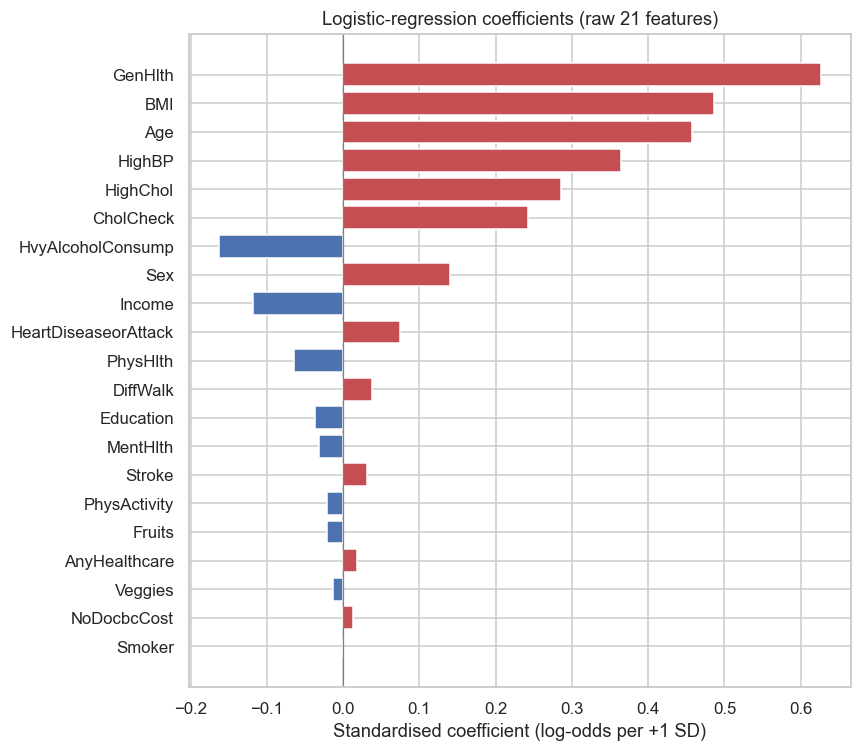

In [9]:
logreg_pipe.fit(X_train, y_train)
coefs = logreg_pipe.named_steps["clf"].coef_[0]

coef_df = (pd.DataFrame({
        "feature": ALL_FEATURES,
        "coef_std": coefs,
        "odds_ratio": np.exp(coefs),
    })
    .sort_values("coef_std", key=np.abs, ascending=False)
    .reset_index(drop=True))
coef_df[["coef_std", "odds_ratio"]] = coef_df[["coef_std", "odds_ratio"]].round(3)
coef_df.to_csv(OUTPUT_DIR / "logreg_coefficients.csv", index=False)
print(coef_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 7))
d = coef_df.iloc[::-1]
ax.barh(d["feature"], d["coef_std"],
        color=["#C44E52" if c > 0 else "#4C72B0" for c in d["coef_std"]], edgecolor="white")
ax.axvline(0, color="grey", lw=0.8)
ax.set_xlabel("Standardised coefficient (log-odds per +1 SD)")
ax.set_title("Logistic-regression coefficients (raw 21 features)")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "logreg_coefficients.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Summary & outlook

**Performance band.** The PR-AUC floor sits at the positive-class prevalence (~0.14) — any classifier that learns from the data must clear this to add value. LogReg on raw features with balanced class weights establishes the linear ceiling; LightGBM with default hyperparameters and scale_pos_weight sits above it and represents the untuned tree ceiling. The gap between them is the empirical upper bound on what non-linearity and automatic interaction detection contribute over a well-regularised linear model on these features.

**Linear vs. non-linear reading.** If the LogReg↔LightGBM gap is small, a well-engineered linear model is competitive and feature engineering (NB05) is the primary lever. If the gap is large, tree-based methods have a structural advantage. This reading sets the expectation for NB05: feature engineering should help LogReg more than LightGBM, because LightGBM already discovers many interactions internally.

**VIF verdict.** Features with VIF < 5 have coefficients that can be read in isolation. Features with high VIF (if any) should be interpreted cautiously — their individual coefficients are unstable, though the overall model prediction is unaffected. VIF is diagnostic only; no feature is removed.

**Threshold metrics.** Confusion matrix and threshold metrics (precision / recall / F1) are threshold-dependent and are therefore produced in NB08, at the use-case threshold (Recall ≥ 0.80) on the final model — not at an arbitrary 0.5 cutoff here.

**No feature was selected or removed in this notebook.** All 21 raw features are carried forward. Feature selection is multivariate and done inside CV in NB06/NB07 where it can be properly evaluated against held-out folds. Feature importance is examined later: permutation importance is used in NB05 to explain FE deltas, and on the final model in NB08.

**Outlook.**
- **NB05 (Feature Engineering):** construct and evaluate feature transformations (BMI encodings, hurdle encoding for count features, composite risk scores) against this baseline band. Only transformations that improve CV PR-AUC beyond the std band are retained.
- **NB06/NB07 (Comparison / Imbalance / Tuning / Stacking):** systematic comparison of imbalance strategies (SMOTE vs. class_weight), hyperparameter optimisation, and model stacking — all judged against NB04's band.
- **NB08 (Evaluation):** threshold selection on OOF scores with a Recall ≥ 0.80 constraint; one-time test-set evaluation; subgroup performance (sex, age, income); calibration (Brier score, calibration plot); permutation importance on the final model; false-positive profiling against the label-noise ceiling.

## References

- Saito, T., & Rehmsmeier, M. (2015). The precision-recall plot is more informative than the ROC plot when evaluating binary classifiers on imbalanced datasets. *PLOS ONE, 10*(3), e0118432. https://doi.org/10.1371/journal.pone.0118432
- UCI Machine Learning Repository. *CDC Diabetes Health Indicators* (Dataset #891). https://archive.ics.uci.edu/dataset/891/cdc+diabetes+health+indicators
- O'Brien, R. M. (2007). A caution regarding rules of thumb for variance inflation factors. *Quality & Quantity, 41*(5), 673–690. https://doi.org/10.1007/s11135-006-9018-6